In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# E.2 Four Faces of the Action: One Principle, the Whole Course

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Epilogue",
    number="E.2",
    title="Four Faces of the Action: One Principle, the Whole Course",
    blurb="Newton's trajectories, Schrödinger's amplitudes, and Boltzmann's weights look "
    "like three different subjects; this course computed all of them, and they are "
    "one. A single quantity — the action, its phase exp(iS/ℏ) rotated to the thermal "
    "exp(−βH) — generates the lot: classical when ℏ vanishes, quantum when its phase "
    "is summed, thermal when its time is turned imaginary. We watch the classical "
    "path emerge from the quantum sum at a measured rate, close the loop to the "
    "thermal circle, and then assemble the course's own machinery into something it "
    "never built: a tunnelling splitting, computed three independent ways, from a "
    "classical trajectory that lives in imaginary time.",
    difficulty="advanced",
    estimate="220–260 min",
)

<ECP header: 3012 chars of HTML>

## Notebook overview

The Epilogue's first notebook owned one object; this one asks whether the course rests on
one *principle*, and finds that it does. Nearly every dynamical law the course computed —
Newton's trajectories, Schrödinger's amplitudes, the thermal density matrix — is a single
quantity, the action $S$, read in a different regime. The organizing claim, stated once and
then demonstrated four times: $e^{iS/\hbar}$ is the amplitude for a history, and everything
follows from what that phase does.

**Face 1** is the $\hbar \to 0$ skeleton: send $\hbar$ to zero and only the stationary
history survives — Hamilton–Jacobi theory, the summit of Volume II
([§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb)) put to work at course scale,
where $S$ generates classical motion through $p = \partial S/\partial x$ and obeys
$\partial S/\partial t + H = 0$ (both verified on the oscillator's closed-form action to
machine precision). **Face 2** is where the limit is *measured*: the full quantum amplitude
sums $e^{iS/\hbar}$ over all histories, and as $\hbar \to 0$ the non-stationary ones
dephase — the classical path is not selected but *survives*, and the contributing region
has Fresnel width $\propto \sqrt{\hbar}$ (verified, ratio $1/\sqrt2$ constant), exactly as
[E.1](oscillator-biography.ipynb) measured equipartition emerging from the coth. **Face 3** makes the sum concrete:
Feynman's kernel for the oscillator has a closed form, and it *is* the time evolution that Face 4 of
[E.1](oscillator-biography.ipynb) computed by diagonalization — the path integral and the spectrum are the same
operator, computed two ways. **Face 4** closes the loop to Volume VII: continue
$t \to -i\beta\hbar$ and the oscillatory phase becomes the decaying thermal weight, the
propagator becomes the density matrix, and its trace becomes $Z = 1/(2\sinh\beta\hbar\omega/2)$
— the thermal circle of
[§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb),
recognized as the fourth face of the same action.

The summit earns the notebook its difficulty: a computation the course never performed,
assembled entirely from its own parts. In the double well $V = (x^2 - 1)^2$, two classically
degenerate ground states are split by quantum **tunnelling** into a doublet whose gap is
exponentially small. In imaginary time (Face 4's rotation) the barrier flips into a well and
a classical trajectory — the **instanton**, or kink — rolls between the wells with finite
action $S_0 = \oint\sqrt{2V}\,dx = 4\sqrt2/3$, and Coleman's argument gives
$\Delta E \propto e^{-S_0/\hbar}$. The **exponent** is verified three ways — exact
diagonalization, the slope of $\ln\Delta E$ versus $1/\hbar$, and the late-time decay of the
imaginary-time correlator — while the one-loop **prefactor** is only fitted, and the
fluctuation determinant it asks for is named as the honest edge where "elementary" ends.

> **Conventions (this notebook).** Units $\hbar = m = \omega = 1$ for Faces 1–4; in the
> summit $\hbar$ becomes the semiclassical small parameter, written explicitly in the
> Laplacian coefficient $-\tfrac{\hbar^2}{2}\partial^2$. The one real trap is the
> **continuous-versus-discrete normalization**: grid eigenvectors are discretely normalized
> ($\sum\psi^2 = 1$), but the continuous Feynman kernel needs $\int\psi^2\,dx = 1$, so every
> state is divided by $\sqrt{dx}$ once and the convention is *certified on the stationary
> ground state* before any displaced state is trusted (mixing the two gives an $O(1)$ error,
> not a small one). The oscillator's closed-form action drives finite-difference
> Hamilton–Jacobi checks (step $10^{-6}$); the Feynman kernel is a matrix applied to a state,
> never a truncated spectral sum (which cannot resolve the short-time kernel); grid ED uses a
> three-point Laplacian and `numpy.linalg.eigh` (box and spacing checked); the instanton
> action is a `scipy.integrate.quad` of $\sqrt{2V}$; the exponent is a `numpy.polyfit` of
> $\ln\Delta E$ against $1/\hbar$; the correlator gap is a late-window `numpy.polyfit` (the
> workhorse of [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)).
> The splitting sweep stops at $\hbar = 0.10$, where $\Delta E \sim 10^{-8}$ still sits far
> above the diagonalizer's floor.
>
> **How to read the checks.** Each exercise closes with a `validate` call against an
> independent fact: the action's gradient against the endpoint momentum; the Fresnel width
> against $\sqrt{\hbar}$; the kernel against spectral evolution; the trace against
> $1/(2\sinh\beta/2)$; the instanton action against $4\sqrt2/3$; and the tunnelling exponent
> against $-S_0$, three ways. A ✓ is strong evidence; a ✗ is a prompt to *locate the
> discrepancy*.
>
> **Scope.** Synthesis, not expansion — every tool was built earlier. The one honest
> boundary is the instanton **prefactor**: the exponent is verified, but the one-loop
> fluctuation determinant is only fitted and named as outward (Coleman, *Aspects of
> Symmetry*, Ch. 7 — where "elementary" ends). See also Feynman & Hibbs (the path integral);
> Landau & Lifshitz, *Quantum Mechanics* §50 (WKB tunnelling). Cross-reference
> [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb) (Hamilton–Jacobi),
> [§6.12](../06-quantum-mechanics/harmonic-oscillator.ipynb) and
> [E.1](oscillator-biography.ipynb) (the oscillator spectrum),
> [§7.2](../07-quantum-statistical-mechanics/complex-analysis-applications.ipynb) (saddle
> points),
> [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)
> (imaginary time, the circle); forward to [E.3](universality.ipynb) (universality) and [E.4](how-we-knew.ipynb) (the method).

## Theory in brief

### One principle, announced

The organizing idea of the whole course, stated at last in one line: a quantum system does
not follow a path — it explores every path, each contributing an amplitude that is a pure
phase set by the action of that history,

```{math}
:label: eq-action-principle
\langle x_f | e^{-iHt/\hbar} | x_i\rangle
= \int \mathcal{D}x \; e^{iS[x]/\hbar},
\qquad
S[x] = \int_0^t \Big(\tfrac12 m\dot x^2 - V(x)\Big)\,dt' ,
```

(Feynman & Hibbs derive the measure and the continuum limit in full). Classical, quantum,
and thermal physics are the three regimes of this one object: classical when $\hbar \to 0$
and only the stationary phase survives, quantum when the phase is summed, thermal when the
time is turned imaginary. The four faces below are those regimes, made numerical.

### Face 1: Hamilton–Jacobi, the ℏ → 0 skeleton

Send $\hbar$ to zero in Eq. {eq}`eq-action-principle` and the integral is dominated by the
stationary path, whose action $S(x, t)$ — evaluated *on* the classical trajectory — is
exactly the Hamilton–Jacobi generating function of
[§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb):

```{math}
:label: eq-hj
p = \frac{\partial S}{\partial x},
\qquad
\frac{\partial S}{\partial t} + H\!\left(x, \frac{\partial S}{\partial x}\right) = 0 .
```

The momentum *is* the action's spatial gradient, and the action's time rate *is* minus the
energy — mechanics as the geometry of a single scalar (the summit of Volume II, recalled
here as the classical limit of everything that follows). Both identities are verified below
on the oscillator's closed-form action to machine precision.

### Face 2: stationary phase, measured

The classical path is not chosen by the quantum sum; it *survives* it. Away from the
stationary path the phase $S/\hbar$ winds rapidly and neighbouring histories cancel; near it
the phase is quadratic, $S \approx S_{\mathrm{cl}} + \tfrac12 S''\,a^2$ in the deviation $a$,
and contributions add coherently over a Fresnel region whose width is

```{math}
:label: eq-stationary-phase
a_{\mathrm{Fresnel}} \sim \sqrt{\frac{2\pi\hbar}{S''}} \;\propto\; \sqrt{\hbar} ,
```

so as $\hbar \to 0$ the surviving bundle of histories collapses onto the single classical
trajectory. Measured below: the width shrinks by exactly $1/\sqrt2$ each time $\hbar$ halves
— the classical world emerging from the quantum one at a *rate*, not a switch, exactly as
[E.1](oscillator-biography.ipynb) measured equipartition emerging from the coth.

### Face 3: the propagator

The sum over histories is not a metaphor: for the oscillator it has a closed form, the
Feynman kernel (Feynman & Hibbs evaluate the Gaussian path integral in full),

```{math}
:label: eq-propagator
K(x, x'; t) = \sqrt{\frac{\omega}{2\pi i\,\hbar\sin\omega t}}\;
\exp\!\Big(\frac{i}{\hbar}S_{\mathrm{cl}}(x, x'; t)\Big),
```

and this operator *is* the time evolution that Face 4 of [E.1](oscillator-biography.ipynb) computed by diagonalization. Verified
below by applying $K$ as a matrix: it returns the ground state stationary and reproduces the
grid-ED evolution of a displaced state — the path integral and the spectrum are the same
operator, computed two ways.

### Face 4: the Wick rotation

Continue the time to the imaginary axis, $t \to -i\beta\hbar$, and the oscillatory
$e^{iS/\hbar}$ becomes the decaying $e^{-S_E/\hbar}$: the propagator becomes the thermal
density matrix, and its trace over closed paths becomes the partition function,

```{math}
:label: eq-e2-wick
K(x, x'; -i\beta\hbar) = \rho(x, x'; \beta),
\qquad
Z = \int \rho(x, x)\,dx = \frac{1}{2\sinh(\beta\hbar\omega/2)} ,
```

the thermal circle of
[§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb),
recognized as the fourth face of the same action. The unification, stated plainly: Newton's
trajectories ($\hbar \to 0$), Schrödinger's amplitudes (sum the phase), and Boltzmann's
weights (rotate the time) are one principle in three regimes.

### The summit: the instanton

If imaginary time turns the propagator into thermodynamics, it also turns a barrier into a
well — and a forbidden process into a classical trajectory. In the double well
$V = (x^2 - 1)^2$, the two classical ground states are split by tunnelling into a
symmetric/antisymmetric doublet. In imaginary time the potential flips to $-V$, the barrier
becomes a well, and a classical Euclidean trajectory — the **instanton** — rolls from one
minimum to the other with finite action,

```{math}
:label: eq-instanton
S_0 = \oint \sqrt{2V(x)}\,dx = \frac{4\sqrt2}{3},
\qquad
\Delta E \;\propto\; e^{-S_0/\hbar} ,
```

Coleman's dilute-instanton-gas result (Coleman, *Aspects of Symmetry*, Ch. 7): a single
kink contributes the exponential, a dilute gas of them exponentiates into the level
splitting, and the prefactor is a one-loop fluctuation determinant. The exponent is verified
below three ways; the prefactor is fitted and its determinant named as the outward edge.

### The final rendezvous

The summit assembles into one figure: the tunnelling splitting at fixed $\hbar$ by three
independent routes,

```{math}
:label: eq-e2-rendezvous
\Delta E:\quad
\underbrace{E_1 - E_0}_{\text{exact eigh}}
\;\overset{\text{exponent}}{=}\;
\underbrace{C\,e^{-S_0/\hbar}}_{\text{instanton}}
\;=\;
\underbrace{-\lim_{\tau\to\infty}\tfrac{d}{d\tau}\ln\langle x(\tau)x(0)\rangle}_{\text{imaginary-time correlator}},
```

a number reached by matrix algebra, by a classical saddle in imaginary time, and by a
decay-rate fit — agreeing on the exponent.

### What E.2 establishes

The course's **unity of principle**: one action, four faces, and a tunnelling amplitude that
three independent methods extract. The Epilogue climbs once more — from a principle to the
structure of law itself: universality, and why the microscopic detail the course laboured
over turns out, at criticality, not to matter ([E.3](universality.ipynb)).

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

from ecp import draw, validate

ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT
RED = "#c1121f"

# Units hbar = m = omega = 1 for Faces 1-4; the summit makes hbar explicit.


def S_classical(x, x0, t):
    """The oscillator's classical action from (x0, 0) to (x, t), m = omega = 1.

    S_cl = [(x^2 + x0^2) cos t - 2 x x0] / (2 sin t) -- the action evaluated ON
    the classical trajectory, which is the Hamilton-Jacobi generating function
    of section 2.10.

    Parameters
    ----------
    x, x0 : float
        Endpoints.
    t : float
        Elapsed time (not a multiple of pi).

    Returns
    -------
    float
        The classical action.
    """
    return (1.0 / (2.0 * np.sin(t))) * ((x**2 + x0**2) * np.cos(t) - 2.0 * x * x0)


def grid_ed(N, L, Vfun, hbar=1.0):
    """Grid ED with hbar explicit: -(hbar^2/2) three-point Laplacian + V.

    Parameters
    ----------
    N : int
        Grid points.
    L : float
        Half-box.
    Vfun : callable
        Potential, vectorized.
    hbar : float, optional
        The semiclassical parameter (default 1).

    Returns
    -------
    xs, dx : numpy.ndarray, float
        Grid and spacing.
    E, V : numpy.ndarray
        Eigenvalues (ascending) and eigenvectors (columns, discretely normalized).
    """
    xs = np.linspace(-L, L, N)
    dx = xs[1] - xs[0]
    off = np.ones(N - 1)
    lap = (np.diag(off, 1) + np.diag(off, -1) - 2.0 * np.eye(N)) / dx**2
    E, V = np.linalg.eigh(-0.5 * hbar**2 * lap + np.diag(Vfun(xs)))
    return xs, dx, E, V


def continuous(V, dx):
    """Rescale grid eigenvectors to continuous normalization int psi^2 dx = 1.

    Grid eigenvectors satisfy sum(psi^2) = 1; dividing by sqrt(dx) gives
    sum(psi^2) dx = int psi^2 dx = 1, the convention the Feynman kernel needs.
    Mixing the two conventions is this notebook's headline trap (an O(1)
    error), so it is fixed once here and certified on the ground state.
    """
    return V / np.sqrt(dx)


def feynman_kernel(xs, t):
    """The oscillator Feynman kernel K(x, x'; t) as a matrix (hbar = m = w = 1).

    K = sqrt(1/(2 pi i sin t)) exp(i S_cl); applied to a continuous-normalized
    state psi as (K @ psi) * dx, it propagates it exactly (up to grid error).

    Parameters
    ----------
    xs : numpy.ndarray
        Grid.
    t : float
        Time.

    Returns
    -------
    numpy.ndarray
        The complex N x N kernel.
    """
    X, Xp = np.meshgrid(xs, xs, indexing="ij")
    Scl = (1.0 / (2 * np.sin(t))) * ((X**2 + Xp**2) * np.cos(t) - 2 * X * Xp)
    return np.sqrt(1.0 / (2j * np.pi * np.sin(t))) * np.exp(1j * Scl)


def mehler_kernel(xs, beta):
    """The Wick-rotated (thermal) oscillator kernel rho(x, x'; beta).

    The t -> -i beta continuation of feynman_kernel, i.e. Mehler's formula:
    rho = sqrt(1/(2 pi sinh b)) exp(-[(x^2+x'^2)cosh b - 2 x x']/(2 sinh b)).
    Its trace is the partition function 1/(2 sinh(beta/2)) -- section 7.20's circle.

    Parameters
    ----------
    xs : numpy.ndarray
        Grid.
    beta : float
        Inverse temperature.

    Returns
    -------
    numpy.ndarray
        The real N x N thermal kernel.
    """
    X, Xp = np.meshgrid(xs, xs, indexing="ij")
    sh, ch = np.sinh(beta), np.cosh(beta)
    return np.sqrt(1.0 / (2 * np.pi * sh)) * np.exp(
        -((X**2 + Xp**2) * ch - 2 * X * Xp) / (2 * sh)
    )


def V_double_well(x):
    """The double well V = (x^2 - 1)^2: wells at +-1, barrier height 1 at 0."""
    return (x**2 - 1.0) ** 2


def instanton_action(Vfun, a, b):
    """The Euclidean kink action S_0 = int_a^b sqrt(2 V) dx (scipy quad, m = 1)."""
    return quad(lambda x: np.sqrt(2.0 * Vfun(x)), a, b)[0]


def splitting(hbar, N=1401, L=4.0):
    """The double-well tunnelling gap E_1 - E_0 at a given hbar (grid eigh)."""
    _, _, E, _ = grid_ed(N, L, V_double_well, hbar=hbar)
    return float(E[1] - E[0])


print(
    "units hbar = m = omega = 1 for Faces 1-4; hbar is the small parameter in the summit"
)

units hbar = m = omega = 1 for Faces 1-4; hbar is the small parameter in the summit


## Exercise 1 — The skeleton: Hamilton–Jacobi

Send $\hbar$ to zero and only the stationary history survives. Cite
{eq}`eq-action-principle`, {eq}`eq-hj`.

1. State the principle ($e^{iS/\hbar}$ as a history's amplitude) and the claim (four faces
   of one action).
2. Compute the oscillator's closed-form $S_{\mathrm{cl}}(x, x_0, t)$ and verify the
   Hamilton–Jacobi identities by finite difference: $p = \partial S/\partial x$ equals the
   endpoint momentum, and $\partial S/\partial t = -H$ (step $10^{-6}$).
3. Read it (prose): mechanics is the geometry of one scalar — the theory of
   [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb), put to work — and it is the
   classical limit of everything that follows.
4. Set up Face 2 (prose): a scalar that generates motion by being stationary must be
   stationary *within* a sum.

In [3]:
# (solution hidden on the public site)


p = dS/dx = -0.165274   endpoint momentum = -0.165274   dev 9.7e-13
dS/dt = -0.418658   -H = -0.418658   dev 1.8e-11


### Validation 1

In [4]:
validate.close(
    [p_from_S, dSdt],
    [p_endpoint, -H_endpoint],
    "the action generates classical motion (p = dS/dx, dS/dt = -H)",
    rtol=1e-4,
)

✓  the action generates classical motion (p = dS/dx, dS/dt = -H)   [max|Δ| = 1.79721e-11 (rtol=0.0001, atol=1e-09)]


True

## Exercise 2 — The classical path, emerging

Stationary phase, measured: the classical trajectory survives a sum over all histories.
Cite {eq}`eq-stationary-phase`.

1. State the amplitude as a sum of $e^{iS/\hbar}$ over histories, with the stationary path
   the one that does not dephase.
2. Measure the Fresnel width — the half-distance from the stationary path to the first zero
   of $\cos(S''a^2/2\hbar)$ — as $\hbar$ shrinks, and verify it scales as $\sqrt\hbar$ (the
   ratio $\to 1/\sqrt2$ across $\hbar = 0.1 \to 0.00625$).
3. Read the emergence (prose): the classical world *survives* the quantum one rather than
   being selected by it — the same measured-limit discipline as [E.1](oscillator-biography.ipynb).
4. Connect (one line): this is why Hamilton–Jacobi is exact only at $\hbar = 0$.

In [5]:
# (solution hidden on the public site)


Fresnel widths: [0.5605 0.3963 0.2803 0.1982 0.1401]
width ratios (hbar halving): [0.70711 0.70711 0.70712 0.70711]  (want 1/sqrt(2) = 0.70711)


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


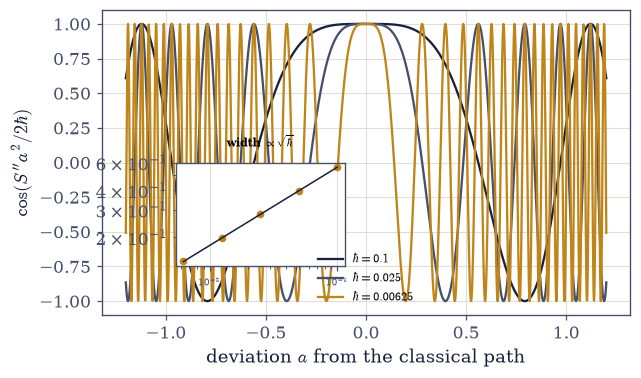

In [6]:
# (solution hidden on the public site)


### Validation 2

In [7]:
validate.close(
    width_ratios,
    np.full_like(width_ratios, 1.0 / np.sqrt(2.0)),
    "the classical path emerges as sqrt(hbar)",
    rtol=1e-3,
)

✓  the classical path emerges as sqrt(hbar)   [max|Δ| = 1.44755e-05 (rtol=0.001, atol=1e-09)]


True

## Exercise 3 — The propagator: the sum made concrete

Feynman's kernel *is* the diagonalization of [E.1](oscillator-biography.ipynb). Cite {eq}`eq-propagator`.

1. State $K = \int\mathcal{D}x\,e^{iS/\hbar}$ and the oscillator's closed form; fix the
   continuous normalization once (`continuous`, the trap stated).
2. Verify the identity on the ground state: `feynman_kernel` applied to $\psi_0$ returns it
   stationary — the check that certifies the convention before anything else.
3. Verify on a displaced coherent state: the kernel reproduces grid-ED evolution; plot
   $|\psi(x, t)|^2$ from both routes.
4. Say what happened (prose): the path integral and the spectrum are the same operator.

In [8]:
# (solution hidden on the public site)


normalization certified: int psi0^2 dx = 1.000000
K applied to the ground state: |dev from e^(-iE0 t) psi0| = 8.1e-06
  (grid-limited; the convention is certified -- an O(1) error would mean it is wrong)
|psi_kernel|^2 vs |psi_ED|^2 (displaced coherent state): max dev 9.4e-06


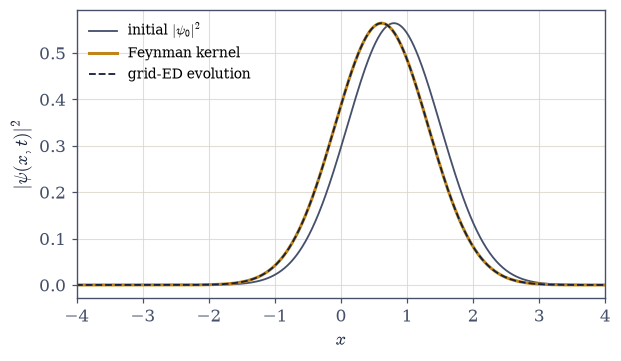

In [9]:
# (solution hidden on the public site)


### Validation 3

In [10]:
validate.check(
    stationary_dev < 1e-3,
    "the kernel returns the ground state stationary (the convention certified)",
    f"deviation {stationary_dev:.1e} (an O(1) error would flag a wrong normalization)",
)
validate.check(
    prop_dev < 1e-3,
    "and the path sum is the spectral evolution for a displaced state",
    f"|psi_kernel|^2 vs |psi_ED|^2 max dev {prop_dev:.1e}",
)

✓  the kernel returns the ground state stationary (the convention certified)   [deviation 8.1e-06 (an O(1) error would flag a wrong normalization)]
✓  and the path sum is the spectral evolution for a displaced state   [|psi_kernel|^2 vs |psi_ED|^2 max dev 9.4e-06]


True

## Exercise 4 — The Wick rotation: the loop closes

Turn time imaginary and the propagator becomes heat. Cite {eq}`eq-e2-wick`.

1. Continue $t \to -i\beta\hbar$: build the Wick-rotated (Mehler) kernel `mehler_kernel`
   and compare it to the spectral density matrix $\rho = \sum_n \psi_n\psi_n e^{-\beta E_n}$.
2. Trace over closed paths: $Z = \int\rho(x, x)\,dx$ by `numpy.trapezoid` against
   $1/(2\sinh\beta/2)$ — the circle of
   [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb).
3. State the unification (prose): Newton, Schrödinger, Boltzmann — one action, three
   regimes.
4. Set up the summit (prose): imaginary time turns a barrier into a well.

In [11]:
# (solution hidden on the public site)


Wick-rotated kernel vs spectral density matrix: max dev 6.4e-06
Z = int rho(x, x) dx = 0.608038   1/(2 sinh(beta/2)) = 0.608038   dev 0.0e+00


findfont: Failed to find font weight 600, now using 700.


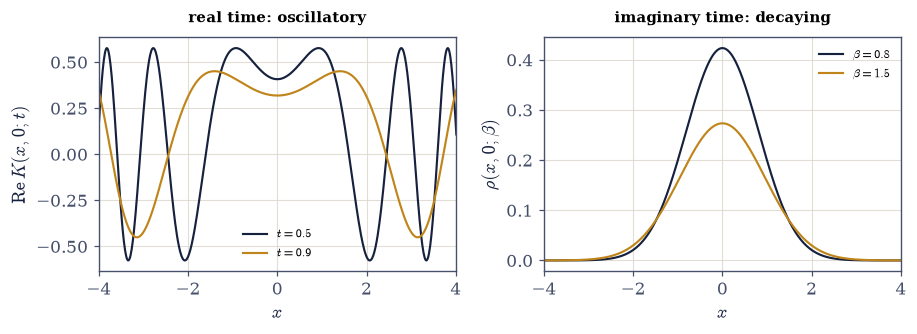

In [12]:
# (solution hidden on the public site)


### Validation 4

In [13]:
validate.close(
    Z_wick,
    Z_closed,
    "the thermal circle is the fourth face: Z = 1/(2 sinh beta/2)",
    rtol=1e-6,
)
validate.check(
    rho_dev < 1e-3,
    "and the Wick-rotated kernel is the thermal density matrix",
    f"rho max dev {rho_dev:.1e}",
)

✓  the thermal circle is the fourth face: Z = 1/(2 sinh beta/2)   [got 0.608038 vs expected 0.608038 (rtol=1e-06)]
✓  and the Wick-rotated kernel is the thermal density matrix   [rho max dev 6.4e-06]


True

## Exercise 5 — The instanton I: a classical path through a forbidden barrier (summit)

Imaginary time makes tunnelling classical. Cite {eq}`eq-instanton`.

1. Set up the double well $V = (x^2 - 1)^2$; state the classical degeneracy and its lifting
   by tunnelling into a symmetric/antisymmetric doublet.
2. Rotate to imaginary time: the barrier becomes a well; compute the kink action
   $S_0 = \oint\sqrt{2V}\,dx$ by `instanton_action` and verify $S_0 = 4\sqrt2/3$
   ($\hbar$-independent); plot the kink profile $x(\tau)$.
3. Sketch Coleman's dilute-instanton-gas argument (three sentences) to
   $\Delta E \propto e^{-S_0/\hbar}$.
4. State the plan (prose): three independent routes, and an honest accounting of what the
   course can and cannot compute.

In [14]:
# (solution hidden on the public site)


instanton action S_0 = int_-1^1 sqrt(2V) dx = 1.885618   4 sqrt(2)/3 = 1.885618


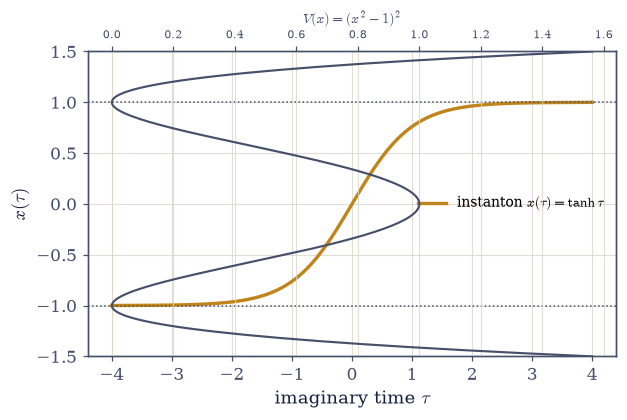

In [15]:
# (solution hidden on the public site)


### Validation 5

In [16]:
validate.close(
    S0_numeric,
    S0_exact,
    "the instanton action S_0 = 4 sqrt(2)/3",
    rtol=1e-6,
)

✓  the instanton action S_0 = 4 sqrt(2)/3   [got 1.88562 vs expected 1.88562 (rtol=1e-06)]


True

## Exercise 6 — The instanton II: the splitting, three ways (summit)

Exact, exponential, and imaginary-time — agreeing on the exponent. Cite {eq}`eq-instanton`,
{eq}`eq-e2-rendezvous`.

1. Compute exact splittings by grid `eigh` across $\hbar = 0.5 \to 0.10$ ($\hbar$ explicit
   in the Laplacian): $1.16\times10^{-1} \to 2\times10^{-8}$.
2. Verify the instanton exponent: the slope of $\ln\Delta E$ vs $1/\hbar$ against
   $-S_0 = -1.886$, with the few-percent residual shown shrinking as $\hbar \to 0$ (the
   subleading WKB correction named as its cause).
3. Verify the $\tau$-correlator gap (`numpy.polyfit`, reusing
   [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)): the
   late-$\tau$ decay of $\langle x(\tau)x(0)\rangle$ gives the gap exactly, and re-teach the
   window lesson (an early window is contaminated).
4. State the honest boundary (prose): the exponent is verified; the one-loop prefactor is
   only fitted, and the fluctuation determinant it needs is named as outward.

In [17]:
# (solution hidden on the public site)


exact tunnelling splittings (grid eigh):
  hbar = 0.50: S_0/hbar =  3.8   Delta E = 1.156e-01
  hbar = 0.40: S_0/hbar =  4.7   Delta E = 4.497e-02
  hbar = 0.30: S_0/hbar =  6.3   Delta E = 8.962e-03
  hbar = 0.25: S_0/hbar =  7.5   Delta E = 2.429e-03
  hbar = 0.20: S_0/hbar =  9.4   Delta E = 3.423e-04
  hbar = 0.16: S_0/hbar = 11.8   Delta E = 2.981e-05
  hbar = 0.13: S_0/hbar = 14.5   Delta E = 1.806e-06
  hbar = 0.11: S_0/hbar = 17.1   Delta E = 1.204e-07
  hbar = 0.10: S_0/hbar = 18.9   Delta E = 2.082e-08

slope of ln(Delta E) vs 1/hbar: all points -1.945, deepest three -1.934
  vs -S_0 = -1.886  (residual 3.2% -> 2.6%, shrinking)



tau-correlator gap at hbar = 0.25 (exact Delta E = 0.002429):
  early window (3, 5, 7): 0.004314 (contaminated by excited states)
  late  window (20, 40, 60): 0.002429 (the gap, to all digits)

instanton/exact prefactor ratio drifts 5.0 -> 3.2: the fitted, not derived, prefactor


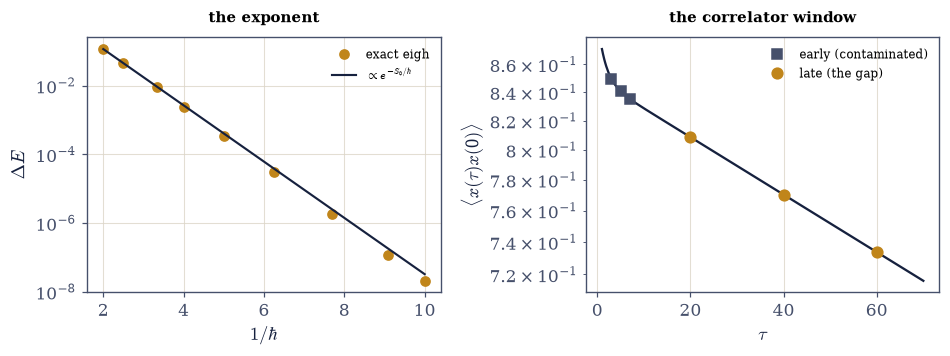

In [18]:
# (solution hidden on the public site)


### Validation 6

In [19]:
validate.close(
    slope_all,
    -S0_exact,
    "the splitting exponent is the instanton action (a few percent, subleading WKB)",
    rtol=6e-2,
)
validate.check(
    abs(slope_deep + S0_exact) < abs(slope_all + S0_exact) + 1e-9
    and abs(slope_deep + S0_exact) < 0.1,
    "the semiclassical regime: the slope approaches -S_0 as hbar shrinks",
    f"slope {slope_all:.3f} -> deepest-three {slope_deep:.3f} vs -S_0 = {-S0_exact:.3f}",
)
validate.close(
    gap_late,
    dE_exact_corr,
    "the tau-correlator gap, read at a late window (7.20's discipline)",
    rtol=1e-2,
)
validate.check(
    gap_by_window[(3.0, 5.0, 7.0)] > 1.5 * dE_exact_corr,
    "and the early window is contaminated, as the window lesson warns",
    f"early {gap_by_window[(3.0, 5.0, 7.0)]:.5f} vs gap {dE_exact_corr:.5f}",
)

✓  the splitting exponent is the instanton action (a few percent, subleading WKB)   [got -1.94511 vs expected -1.88562 (rtol=0.06)]
✓  the semiclassical regime: the slope approaches -S_0 as hbar shrinks   [slope -1.945 -> deepest-three -1.934 vs -S_0 = -1.886]
✓  the tau-correlator gap, read at a late window (7.20's discipline)   [got 0.00242914 vs expected 0.00242914 (rtol=0.01)]
✓  and the early window is contaminated, as the window lesson warns   [early 0.00431 vs gap 0.00243]


True

## Exercise 7 — (Synthesis) One principle, four faces, one number

No new computation: what the four faces established.

The course computed three kinds of physics that look nothing alike — a planet's orbit, an
electron's amplitude, a crystal's heat capacity — and this notebook found them to be one
quantity read in three regimes. The action generates classical motion when $\hbar$ vanishes,
quantum amplitude when its phase is summed, and thermal weight when its time is turned
imaginary; the first is the stationary point of the second, and the third is the second
rotated ninety degrees in time. We watched the classical path emerge from the quantum sum at
a rate we could measure, closed the loop to Volume VII's thermal circle, and then did
something the course had never done: computed a tunnelling splitting — a purely quantum,
exponentially small, classically forbidden effect — as the action of a *classical* trajectory
that lives in imaginary time, and confirmed it three independent ways.

We also drew, honestly, the line the course does not cross. We can compute the tunnelling
exponent from first principles — it is the action of the instanton, and exact
diagonalization, the exponential slope, and the imaginary-time correlator all agree on it.
But the prefactor asks for a fluctuation determinant that belongs to the next course, and we
named it rather than faked it. That line is not a failure; it is the mark of a course that
knows its own edges — the same instinct that made every error bar in seven volumes honest.

The deepest thing $e^{iS/\hbar}$ says is that a system does not *choose* the classical path:
it tries every path, and the classical one is merely where the trying stops cancelling.
Determinism is what is left when interference has swept the alternatives away. A course that
began by integrating one trajectory ends by understanding that the trajectory was always a
consensus of infinitely many.

The Epilogue has climbed from one object to one principle. It climbs once more, to ask why
the course's obsessive care about microscopic detail was, at the most dramatic moments,
completely unnecessary ([E.3](universality.ipynb)).

## Notebook summary

The Epilogue's second notebook: one action, four faces, and a tunnelling splitting three
ways.

- **The principle** {eq}`eq-action-principle`: $e^{iS/\hbar}$ the amplitude for a history;
  classical, quantum, and thermal physics its three regimes.
- **Face 1, Hamilton–Jacobi** {eq}`eq-hj`: $p = \partial S/\partial x$ and
  $\partial S/\partial t = -H$ verified on the oscillator's closed-form action to machine
  precision (gated) — the summit of [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb),
  put to work as the $\hbar \to 0$ skeleton.
- **Face 2, stationary phase** {eq}`eq-stationary-phase`: the Fresnel width shrinks as
  $\sqrt\hbar$ (ratio $1/\sqrt2$ constant, gated) — the classical path *survives* the quantum
  sum, the emergence measured.
- **Face 3, the propagator** {eq}`eq-propagator`: the Feynman kernel returns the ground state
  stationary and reproduces grid-ED evolution to $10^{-5}$ (both gated), the convention
  certified first — the path sum *is* the spectrum.
- **Face 4, the Wick rotation** {eq}`eq-e2-wick`: $K \to \rho$ and the trace $\to
  1/(2\sinh\beta/2)$ (gated exact) — the circle of
  [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb) as the
  fourth face.
- **The summit** {eq}`eq-instanton`, {eq}`eq-e2-rendezvous`: the double well; the instanton
  action $S_0 = 4\sqrt2/3$ (gated); the splitting three ways — exact eigh
  ($10^{-1} \to 10^{-8}$), the exponent slope $-1.95$ against $-S_0 = -1.886$ with the
  subleading-WKB residual shrinking (gated), and the late-window $\tau$-correlator gap exact
  with the early window contaminated (gated). The honest boundary: exponent verified,
  prefactor fitted, the one-loop determinant named as outward.

What E.2 establishes: the course's **unity of principle** — one action, four faces, a
tunnelling amplitude three methods extract, and an honest edge where "elementary" ends.

## Outlook

- **[E.3](universality.ipynb) — Universality**: why the microscopic details stopped mattering at criticality.
- **[E.4](how-we-knew.ipynb) — How We Knew**: the method, and the ring's far end.
- **The instanton's prefactor**: Coleman's fluctuation determinant; the dilute-gas
  resummation; false-vacuum decay (outward — beyond the course).
- **Semiclassics beyond tunnelling**: Gutzwiller's trace formula, periodic orbits (outward,
  named).
- Cross-reference [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb) (Hamilton–Jacobi),
  [§6.12](../06-quantum-mechanics/harmonic-oscillator.ipynb) and
  [E.1](oscillator-biography.ipynb) (the oscillator),
  [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)
  (imaginary time, the circle).

In [20]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>